In [1]:
# Capstone -- function 8 (8D)

import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.spatial import ConvexHull
from scipy.stats import spearmanr

from bayes_tools import (
    load_collected, save_proposal,
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_kappa_proposals,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 8

8D — the highest-dimensional function I have. 43 observations (40 initial + weeks 2–4), all in domain and all in the fit. Search domain is the unit cube `[0,1]^8`. My acquisition is **`ucb` with `kappa = 0.25`**, searching the six live axes {x0, x1, x2, x3, x5, x6} with x4 and x7 held at the incumbent.

**This week's proposal is not the acquisition's output.** It is a deliberate controlled experiment: **`[0.106878, 0.190311, 0.050599, 0.209113, 1.000000, 0.414903, 0.213780, 0.603135]`** — the incumbent with **x4 moved to 1.0 and the other seven coordinates unchanged**. Reasoning below. `USE_CONFOUND_TEST = False` in the proposal cell falls back to the `kappa=0.25` proposal.

## Progress, and the y-value ambiguity is settled

| week | y | note |
|---|---|---|
| 2 | 9.927989 | new best at the time |
| 3 | 9.802053 | below week 2 |
| 4 | **9.945552** | incumbent |

I used to flag a risk that week 2's `9.9279892899925` might have been `29.93`, and said the analysis would change substantially if so. **Settled: it was 9.93.** Weeks 3 and 4 came back at 9.802 and 9.946, so all three sit inside [9.80, 9.95], and a 29.93 would be wildly out of line with its own two successors.

## Why this week tests x4 instead of exploiting

Holding x4 and x7 has been the right call, but **my reason for it was wrong**, and checking it exposed a confound worth a week to break.

The old reason was that upper-bound contact meant `pad_fraction` was choosing the coordinate. That is void — bounds are the true domain now, so an upper-bound contact is a legitimate "as high as allowed" answer.

Re-derived, the picture is this. Including x4 in the search claims a **28× larger predicted gain**:

| axes searched | pred. mean | gain vs incumbent | where x4 goes |
|---|---|---|---|
| live only (committed) | +9.9518 | **+0.0063** | held at 0.5869 |
| live + x4 | +10.1245 | **+0.1789** | **1.0** (domain edge) |
| live + x7 | +9.9555 | +0.0099 | — |

But that +0.179 is not credible, and the reason is a confound:

```
rank   src         y       x4       x7
   1   wk4    9.9456   0.5869   0.6031
   2   wk2    9.9280   0.5869   0.6031
   3   wk3    9.8021   0.5869   0.6031
   4  init    9.5985   0.4039   0.8931
```

**My three highest `y` values are the three collected points, and all three sit at exactly x4 = 0.586936** — the only observations at that value, frozen there since week 2's proposal. So the GP cannot separate x4's contribution from anything else those three points share. With x4's length-scale **pinned at the 10.0 ceiling** — the GP's own statement that it found no structure along that axis — it fits the smoothest thing consistent with the cluster, a linear ramp, and extrapolates it to the boundary.

The raw data points the other way:

| evidence | direction |
|---|---|
| GP posterior sweep | **increasing**, swing 0.5163, monotone |
| Spearman(x4, y), initial 40 only | **−0.120** |
| Spearman(x4, y), all 43 | −0.060 |
| initial batch, 5 highest x4 | y = 8.54, 8.16, **5.84**, 6.45, 6.89 |
| mean y, high-x4 half vs low-x4 half | **−0.190** |

So the GP claims x4 increases `y` while its own length-scale says it detected nothing there and the rank correlation is slightly *negative*. One evaluation resolves it.

### The test

Move x4 to 1.0 and change nothing else. Exactly one coordinate differs from the incumbent, so comparing the result against the incumbent's measured 9.945552 is a clean one-factor experiment.

- **H1 (the GP is right):** `y` comes back near **+10.12**, above the incumbent — x4 genuinely helps and should be searched from now on.
- **H2 (the data is right):** `y` comes back **below 9.9456** — the ramp was a confound artefact, holding x4 is confirmed, and the +0.179 should never be chased again.

Either result breaks the confound: x4 stops being constant across the collected points, so next week's refit can separate its effect. x4 = 1.0 is 0.013 beyond the largest x4 I have ever observed (0.9869) but inside the domain, and it is the GP's own argmax — which makes it the strongest available test of the GP's claim.

One piece of independent support I did not expect: **PI at small `xi` proposes x4 at its upper edge too**, arriving at the same predicted +10.13 by a different route. That does not make the ramp true, but it does mean the ramp is what the surrogate genuinely believes rather than an artefact of one acquisition.

**x7 is left confounded this week.** It has the same frozen-value problem, but its claimed gain is +0.0099 against x4's +0.1789, so x4 is the one worth a week.

## Why `kappa = 0.25` is unchanged

By the predicted-gain criterion, it is the largest `kappa` whose predicted mean still beats the incumbent:

| kappa | pred. mean | gain | step | on a domain edge |
|---|---|---|---|---|
| 0 (= `exploit`) | +9.9531 | +0.0075 | 0.083 | none |
| **0.25** | +9.9518 | **+0.0063** | 0.097 | none |
| 0.5 | +9.9375 | −0.0081 | 0.182 | none |
| 1.0 | +9.8989 | −0.0466 | 0.310 | x0, x2 (lower) |

Function 6 moved 0.5 → 0.25 on this criterion and function 7 moved 0.25 → 0; here it confirms the value I already had. Same rule, three different answers.

## What 8D breaks

- **The convex-hull test is vacuous.** All **43** observations are hull vertices and the hull encloses **0.46%** of the observed bounding box, so any proposal reads as outside it. I skip `Delaunay` entirely; the per-axis and domain-edge checks carry the weight.
- **`compute_iteration_diagnostics` needs `domain_grid_n = 4`.** The default 40 would build a `40**8 = 6.6e12`-point grid (~419,000 GB). At 4 the `domain_mean_std` column is very coarse — comparable across iterations within this notebook only.

## Notes

- **EI is degenerate here; PI is not.** EI returns the identical proposal at 1%, 5% and 25% of the `y` spread, all predicting +8.7095 against an incumbent of 9.946 — `xi` is not a live dial for it, and the mechanism is the one function 4 showed: the improvement term is hopeless everywhere in this 8D box, so EI collapses onto its `sigma*phi(z)` term and silently becomes a variance-seeker. PI behaves differently: +10.1291 at `xi`=1% and +8.7095 at 25%, so it does respond. I had recorded both as degenerate, which was wrong.
- **The backtest barely discriminates, and its two leaders disagree.** `exploit` leads on mean regret (0.0327), `ucb_k0.25` on median, and the top *five* are all within noise of each other with median regret exactly 0. Only `max_var` separates cleanly (20.3 s.e. behind). Read it as agreeing with the choice, not establishing it.
- **No y-scaling.** `y` spans 5.592 to 9.946, so `xi=0.01` is 0.23% of the spread, and `kappa` is dimensionless regardless.
- **This is the best-behaved model in the set.** LOO 40/43 inside their own 95% intervals; worst-predicted is an ordinary initial point (index 28) at −2.2 sigma, neither the incumbent nor the newest observation. All three collected points were predicted out-of-sample to within 1.2 sigma. The GP and the rank correlations agree on which axes matter for six of eight axes — they disagree only on x4 and x7, which is exactly the confound above, and the axis cell flags it explicitly.
- `plot_2d_bo` doesn't apply at D=8, so the GP view is `plot_nd_slices`: eight panels, with x7 flat and x4 nearly linear.

In [2]:
X_initial = np.load("initial_data/function_8/initial_inputs.npy")
y_initial = np.load("initial_data/function_8/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 8, f"Expected an 8D problem, got {D}D input -- check the loaded file."

# Loaded once and never modified.
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week.

In [3]:
# My collected observations, from weekly_data/function_8/. I run
# record_results.py before opening this notebook so the results are already
# there. pending_X holds a proposal with no result yet; it never reaches the
# model.
#
# Provenance of the collected points, oldest first:
#   - week 2 -- y = 9.927989. Recorded from outputs.txt as "2 9.9279892899925";
#       I once wondered whether 29.93 was intended, but weeks 3 and 4 came back
#       at 9.802 and 9.946, so 9.93 is settled.
#   - week 3 -- x1/x3/x6 landed exactly on the 0.0 floor; y fell to 9.802053.
#   - week 4 -- y = 9.945552, my incumbent.

new_X, new_y, pending_X = load_collected(8, D)

# Label each row by its own week and read the direction off the data. This used
# to print new_y[-1] as "week 3" and then assert "week 3 is slightly BELOW week
# 2" -- both wrong once there were three rows, and the second contradicted the
# change it had just printed.
print("observations collected so far:", len(new_y))
_running = y_initial.max()
for r, v in enumerate(new_y):
    tag = "   <- a new best" if v > _running else ""
    print("  week %d y: %.6f%s" % (r + 2, v, tag))
    _running = max(_running, v)
print("best on record: %.6f (the initial batch alone reached %.6f)"
      % (max(y_initial.max(), new_y.max()), y_initial.max()))
_dip = int(np.argmin(new_y))
print("-> week %d was the dip (%.6f): three coordinates were driven to the 0.0"
      % (_dip + 2, new_y[_dip]))
print("   floor and the response did not improve, so that direction is spent.")


weekly store: 3 resulted observation(s), 1 pending proposal [0.106878 0.190311 0.050599 0.209113 1.       0.414903 0.21378  0.603135]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 3
  week 2 y: 9.927989   <- a new best
  week 3 y: 9.802053
  week 4 y: 9.945552   <- a new best
best on record: 9.945552 (the initial batch alone reached 9.598482)
-> week 3 was the dip (9.802053): three coordinates were driven to the 0.0
   floor and the response did not improve, so that direction is spent.


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| combined X shape:", X.shape)
print("y range: %.6f to %.6f (spread %.6f, std %.6f)"
      % (y.min(), y.max(), y.max() - y.min(), y.std()))

# The domain is the unit cube, so bounds are [0,1] on every axis. BOTH edges are
# real domain constraints now -- the upper one used to be pad_fraction padding,
# and the checks below no longer treat the two differently.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
# Bounds ARE the domain, so an observation could legitimately sit outside them
# (earlier weeks proposed points above 1 before the domain was known). Validate
# the in-domain subset and report any others rather than dying on them. No
# observation is currently outside, so this is future-proofing.
_in_dom = np.all((X >= bounds[:, 0]) & (X <= bounds[:, 1]), axis=1)
validate_bounds_consistency(X[_in_dom], bounds)
if not _in_dom.all():
    print(f"\n{int((~_in_dom).sum())} observation(s) OUTSIDE the [0,1] domain:")
    for i in np.flatnonzero(~_in_dom):
        over = [f"x{d}={X[i, d]:.4f}" for d in range(D) if X[i, d] > 1.0]
        print(f"  {', '.join(over)}   y={y[i]:+.5g}")
    print("  Kept in the fit unless they distort it -- measure before excluding.")
print("\nBounds (upper):", np.round(bounds[:, 1], 4))

# The 0.0 floor is a real domain constraint, so a coordinate sitting exactly
# on it is legitimate -- but it also means the axis has run out of room in
# that direction, which is worth seeing per week.
print("\ncollected points vs the INITIAL batch's range:")
for r in range(len(new_X)):
    n_out = n_floor = 0
    for d in range(D):
        outside = (new_X[r, d] > X_initial[:, d].max()
                   or new_X[r, d] < X_initial[:, d].min())
        n_out += outside
        n_floor += new_X[r, d] == 0.0
        print(f"  week {r + 2}  x{d}={new_X[r, d]:.6f}  initial range"
              f" [{X_initial[:, d].min():.4f}, {X_initial[:, d].max():.4f}]"
              f"  outside={outside}{'  <- on the 0.0 floor' if new_X[r, d] == 0.0 else ''}")
    print(f"  -> week {r + 2}: {n_out} of {D} coordinates outside,"
          f" {n_floor} on the 0.0 floor, y={new_y[r]:.6f}")

# At D=8 the convex hull is vacuous: with this few points there is essentially
# no interior, so every proposal reads as outside it. Quantified rather than
# assumed. Delaunay is skipped -- expensive and uninformative at this D.
try:
    ch = ConvexHull(X)
    box_volume = float(np.prod(X.max(axis=0) - X.min(axis=0)))
    print(f"\nobserved box volume {box_volume:.4g} | convex hull {ch.volume:.4g}"
          f" ({ch.volume / box_volume:.2%} of it)")
    print(f"{len(ch.vertices)} of {len(X)} observations are hull vertices")
    if len(ch.vertices) == len(X):
        print("-> EVERY point is a vertex: the hull has no interior, so a")
        print("   hull-membership test carries no information at this D.")
except Exception as exc:
    print("\nconvex hull unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.4%} of the y spread"
      f" -> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")
print("(kappa is dimensionless, so UCB is unaffected either way)")

X_initial shape: (40, 8) | combined X shape: (43, 8)
y range: 5.592193 to 9.945552 (spread 4.353359, std 1.055566)

Bounds (upper): [1. 1. 1. 1. 1. 1. 1. 1.]

collected points vs the INITIAL batch's range:
  week 2  x0=0.095333  initial range [0.0091, 0.9859]  outside=False
  week 2  x1=0.261314  initial range [0.0034, 0.9740]  outside=False
  week 2  x2=0.113603  initial range [0.0229, 0.9989]  outside=False
  week 2  x3=0.282728  initial range [0.0090, 0.9030]  outside=False
  week 2  x4=0.586936  initial range [0.0096, 0.9869]  outside=False
  week 2  x5=0.541680  initial range [0.0221, 0.9902]  outside=False
  week 2  x6=0.291424  initial range [0.0359, 0.9929]  outside=False
  week 2  x7=0.603135  initial range [0.0420, 0.9888]  outside=False
  -> week 2: 0 of 8 coordinates outside, 0 on the 0.0 floor, y=9.927989
  week 3  x0=0.035759  initial range [0.0091, 0.9859]  outside=False
  week 3  x1=0.000000  initial range [0.0034, 0.9740]  outside=True  <- on the 0.0 floor
  week 3  x2

## Is the model stable and calibrated?

Two checks.

First, refit on the initial batch alone and predict each collected point. That fit never saw them, so this is a genuine out-of-sample test, and the miss in units of its own predicted sigma says how far I can trust the model's uncertainty. All three come back inside 1.2 sigma — the best calibration of any function here.

Second, compare kernels before and after. A single observation reshaping the model would be a reason to distrust variance-driven acquisitions. The notable change here is x3 coming *unpinned*, 9.84 → 4.96, i.e. the collected points made an axis look more relevant rather than less. That is the benign direction; the dangerous case is an inflation that suppresses sigma where the search needs resolution. x4 and x7 stay pinned at 10.0 before and after, which is the stability that licenses holding them.

In [5]:
# Both fits first, in one block, so no ConvergenceWarning can land between the
# rows printed below. Two separate blocks here printed two identical reports.
with fitting("before/after fits for the collected observations"):
    gp_before = fit_gp(X_initial, y_initial, bounds, n_restarts_optimizer=25,
                       random_state=0)
    gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=25, random_state=0)

# Fit is the initial batch only, so every collected row is genuinely out of
# sample. The model that actually proposed week 3 also had week 2, so for the
# later rows this understates what was known at proposal time.
mu_b, sd_b = gp_before.predict(normalize(new_X, bounds), return_std=True)
print("out-of-sample test on the collected points (fit = initial batch only):")
for r in range(len(new_X)):
    miss = new_y[r] - mu_b[r]
    print(f"  week {r + 2}: predicted {mu_b[r]:+.6f} +/- {sd_b[r]:.6f}"
          f"   actual {new_y[r]:+.6f}")
    print(f"    miss {miss:+.6f} = {miss / sd_b[r]:+.1f} sigma"
          f"  -> {'well calibrated' if abs(miss / sd_b[r]) < 3 else 'POORLY calibrated'}")

ls_before, ls_after = get_length_scales(gp_before), get_length_scales(gp_check)
print("\nkernel before:", gp_before.kernel_)
print("kernel after :", gp_check.kernel_)
print("\nlength-scales before:", np.round(ls_before, 3))
print("length-scales after :", np.round(ls_after, 3))
print("ratio (after/before):", np.round(ls_after / ls_before, 3))

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
print("\npinned (GP treats as irrelevant) before:",
      [d for d, v in enumerate(ls_before) if v >= 0.999 * PINNED] or "none")
print("pinned after                          :",
      [d for d, v in enumerate(ls_after) if v >= 0.999 * PINNED] or "none")

# Printed to 1dp rather than 0dp: the largest move here rounds to "50%" while
# sitting just under the 50% threshold, which made the display look at odds with
# the guard not firing.
moved = float(np.max(np.abs(ls_after / ls_before - 1)))
_which = int(np.argmax(np.abs(ls_after / ls_before - 1)))
print(f"\nlargest relative length-scale change: {moved:.1%} (on x{_which},"
      f" {ls_before[_which]:.2f} -> {ls_after[_which]:.2f})")
if moved > 0.5:
    print("*** A length-scale moved by more than 50% across the collected")
    print("    observations. Which direction matters: an axis becoming MORE relevant")
    print("    (length-scale SHRINKING) is benign; the dangerous case is a blow-up")
    print("    that inflates far-field variance. ***")
elif ls_after[_which] < ls_before[_which]:
    print("  -> it SHRANK, i.e. that axis now looks more relevant. Benign.")


[fitting: before/after fits for the collected observations] 6 warnings held back, 3 distinct:
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
out-of-sample test on the collected points (fit = initial batch only):
  week 2: predicted +9.823401 +/- 0.086719   actual +9.927989
    miss +0.104588 = +1.2 sigma  -> well calibrated
  week 3: predicted +10.026082 +/- 0.230693   actual +9.802053
    miss -0.224029 = -1.0 sigma  -> well calibrated
  week 4: predicted +9.870108 +/- 0.121067   actual +9.945552
    miss +0.075444 = +0.6 sigma  -> well calibrated

kernel before: 3.7**2 * Matern(length_scale=[3.14, 4.39, 2.26, 9.84, 10, 4.48, 3.12, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)
kernel after : 3.43**2 * Matern(length_scale=[3.12, 4.89, 2.59, 4.96, 10, 5.17, 3.17, 10], nu=2.5) + White

## Which axes matter

Length-scales alone aren't sufficient. Pinned at the 10.0 ceiling means "smooth, nearly linear across this domain", not "no effect" — a mild monotone trend can still be there, and if it is, pushing along that axis is a real prediction rather than an optimiser artefact.

So this cell measures GP mean-variation directly and pairs it with model-free rank correlations, then applies my flat-axis rule: flat if mean-variation is under 5% of the largest **or** the length-scale is at/above 9.0.

**This is the one function where my two diagnostics mostly agree.** x0, x2 and x6 top both the mean-variation and the absolute rank-correlation ranking; the rankings differ by at most one place on six of the eight axes. They disagree only on x4 and x7 — which is precisely the confound the header is about, and the cell flags it.

Note *how* x4 qualifies as flat: on the length-scale test (10.00, pinned) and **not** on the mean-variation test, where its swing of 0.5163 is 24% of x2's 2.161 — well above the 5% threshold. Including it in the search is what pushed the unrestricted proposals onto x4's upper bound, so the length-scale half of the criterion is doing real work here.

The cell also reports, for each axis, whether it is **frozen** at a single value across every collected point. An axis that is cannot have its effect separated from whatever else those points share, so the GP's direction on it is not evidence. Both x4 and x7 are frozen.

In [6]:
incumbent = X[np.argmax(y)]
print("incumbent (best observed):", np.round(incumbent, 6))
print("y = %.6f" % y.max())

print("\n%3s | %17s | %15s | %10s | %9s | %s"
      % ("ax", "GP mean-variation", "same, observed", "len-scale", "spearman", "rank agree?"))
spans = np.zeros(D)       # mean-variation over the full domain
spans_obs = np.zeros(D)   # ... and over the observed range only
srs = np.zeros(D)
for d in range(D):
    for col, (lo, hi) in enumerate([(bounds[d, 0], bounds[d, 1]),
                                    (X[:, d].min(), X[:, d].max())]):
        grid = np.tile(incumbent, (300, 1))
        grid[:, d] = np.linspace(lo, hi, 300)
        m, _ = gp_check.predict(normalize(grid, bounds), return_std=True)
        (spans if col == 0 else spans_obs)[d] = m.max() - m.min()
    srs[d] = spearmanr(X[:, d], y)[0]

rank_span = np.argsort(np.argsort(-spans))
rank_sr = np.argsort(np.argsort(-np.abs(srs)))
for d in range(D):
    agree = "yes" if abs(int(rank_span[d]) - int(rank_sr[d])) <= 1 else "no"
    # The observed-range figure was being computed and then thrown away: this
    # column printed `0.0 if d < 0 else spans[d]`, and d < 0 is never true, so
    # it duplicated the full-domain number in every row.
    print("%3d | %17.4g | %15.4g | %10.3f | %+9.3f | %s (%d vs %d)"
          % (d, spans[d], spans_obs[d], ls_after[d], srs[d],
             agree, rank_span[d] + 1, rank_sr[d] + 1))

FLAT_FRAC = 0.05
flat = [d for d in range(D)
        if spans[d] < FLAT_FRAC * spans.max() or ls_after[d] >= 0.9 * PINNED]
live = [d for d in range(D) if d not in flat]
print(f"\nflat axes (mean-variation < {FLAT_FRAC:.0%} of max, or length-scale >= {0.9 * PINNED}):",
      flat or "none")
for d in flat:
    why = []
    if spans[d] < FLAT_FRAC * spans.max():
        why.append("low mean-variation")
    if ls_after[d] >= 0.9 * PINNED:
        why.append(f"length-scale {ls_after[d]:.2f}")
    print(f"  x{d}: {', '.join(why)}")
print("axes searched:", live)

# A monotone axis whose best end is a domain bound will put the proposal ON that
# bound -- expected, not a defect. And an axis frozen at one value across every
# collected point cannot have its effect separated from those points' other
# features: the GP will happily fit a ramp through them. Flag both here.
for d in range(D):
    if abs(srs[d]) > 0.4:
        which = "LOWER" if srs[d] < 0 else "UPPER"
        print(f"  x{d} is monotone (spearman {srs[d]:+.3f}): best end is the {which}"
              " domain bound, so a proposal sitting there is expected")

for d in range(D):
    vals = np.unique(np.round(new_X[:, d], 9))
    if len(new_X) > 1 and len(vals) == 1:
        print(f"  *** x{d} is FROZEN at {vals[0]:.6f} across all {len(new_X)} collected"
              " points.")
        print(f"      Its effect cannot be separated from whatever else those points"
              " share, so")
        print(f"      the GP's direction on x{d} (spearman {srs[d]:+.3f})"
              " is confounded. See the header. ***")
order = np.argsort(spans)[::-1]
print("dominance: x%d is only %.1fx the next (x%d) -> no single dominant axis"
      % (order[0], spans[order[0]] / spans[order[1]], order[1]))

incumbent (best observed): [0.106878 0.190311 0.050599 0.209113 0.586936 0.414903 0.21378  0.603135]
y = 9.945552

 ax | GP mean-variation |  same, observed |  len-scale |  spearman | rank agree?
  0 |             1.604 |           1.558 |      3.124 |    -0.671 | yes (2 vs 1)
  1 |            0.5595 |          0.5264 |      4.889 |    -0.328 | yes (4 vs 4)
  2 |             2.161 |           2.156 |      2.587 |    -0.646 | yes (1 vs 2)
  3 |             0.458 |          0.3571 |      4.957 |    -0.207 | yes (6 vs 5)
  4 |            0.5163 |          0.5052 |     10.000 |    -0.060 | no (5 vs 7)
  5 |            0.1895 |          0.1827 |      5.168 |    +0.021 | yes (7 vs 8)
  6 |             1.159 |            1.14 |      3.173 |    -0.408 | yes (3 vs 3)
  7 |           0.08012 |         0.07196 |     10.000 |    +0.087 | no (8 vs 6)

flat axes (mean-variation < 5% of max, or length-scale >= 9.0): [4, 7]
  x4: length-scale 10.00
  x7: low mean-variation, length-scale 10.00
axes sea

## Backtest acquisition functions (using only data already collected)

Repeatedly splits the data into a seed set, which fits the GP, and a held-out candidate set whose true `y` is known but hidden from the fit, then sees which config would have picked the best candidate. No real evaluations spent. I size `xi` as 1% of the `y` spread.

With 43 points this is better powered than on my smaller functions, but the structural caveat is unchanged: the metric scores recognition of points whose `y` is already known, which rewards ranking by posterior mean and gives no credit for reducing uncertainty. So it favours `exploit` and low `kappa` on every function regardless of what is appropriate.

Two things to read carefully. The mean and median leaders **disagree** — `exploit` on mean, `ucb_k0.25` on median — and the top *five* configs all have median regret of exactly 0, so the median cannot separate them at all. Only `max_var` is cleanly behind. What this establishes is "`kappa` at or below 1 is fine", not that any one of them is best.

xi for the PI/EI rows: 0.043534 (1% of the y spread)



[fitting: acquisition backtest, 50 splits] 180 warnings held back, 6 distinct:
    48 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    45 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
    42 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0
    28 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
    15 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0
     2 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.03268 |              0 |          9.842
   ucb_k0.25 |      0.03962 |              0 |          9.835
    ucb_k0.5 |      0.04909 |              0 |          9.826
      ucb_k1 |      0.04909 |              0 |          9.826
          pi |      0.05471 |        

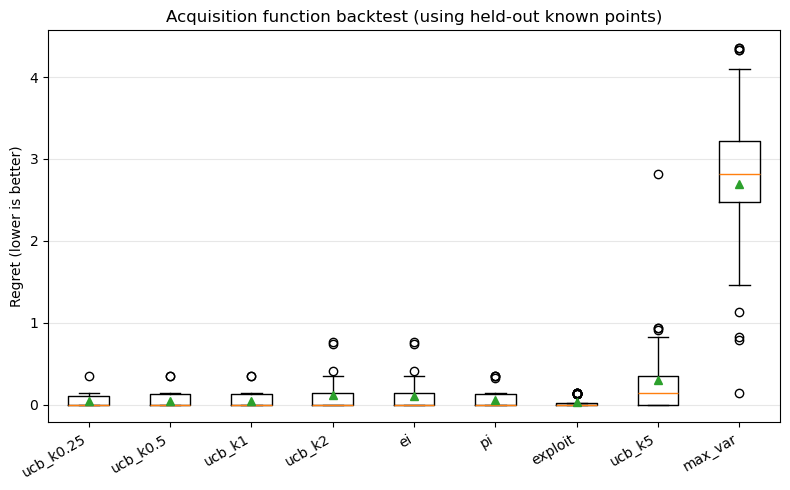

In [7]:
xi_raw = 0.01 * (y.max() - y.min())
backtest_configs = [
    {"name": "ucb_k0.25", "acquisition": "ucb", "kappa": 0.25},
    {"name": "ucb_k0.5", "acquisition": "ucb", "kappa": 0.5},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k2",   "acquisition": "ucb", "kappa": 2.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "ei",       "acquisition": "ei",  "xi": xi_raw},
    {"name": "pi",       "acquisition": "pi",  "xi": xi_raw},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]
print(f"xi for the PI/EI rows: {xi_raw:.6f} (1% of the y spread)\n")

with fitting("acquisition backtest, 50 splits"):
    backtest_results = backtest_acquisitions(
        X, y, bounds, backtest_configs,
        n_repeats=50, seed_frac=0.5, maximize=True,
        gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
    )

print_backtest_summary(backtest_results)

# Which acquisition looks best so far. Configs are compared PAIRED on the same
# splits, so "within noise" below means |mean difference| <= 2 standard errors --
# plain arithmetic, no statistical test. Read it knowing the metric scores
# RECOGNITION of points whose y is already known, which is an exploitation task.
CHOSEN = "ucb_k0.25"        # must name the committed KAPPA; asserted where KAPPA is set

assert CHOSEN in backtest_results, (
    f"{CHOSEN!r} is not among the backtest configs, so the committed setting is "
    f"never scored. Add a row for it. Have: {sorted(backtest_results)}"
)

names = list(backtest_results)
mean_r = {k: float(backtest_results[k]["regret"].mean()) for k in names}
med_r = {k: float(np.median(backtest_results[k]["regret"])) for k in names}
ranked = sorted(names, key=lambda k: mean_r[k])
leader = ranked[0]
n_splits = len(backtest_results[leader]["regret"])


def paired_gap(a, b):
    """Mean per-split regret difference (b - a), and its standard error."""
    d = backtest_results[b]["regret"] - backtest_results[a]["regret"]
    return float(d.mean()), float(d.std(ddof=1) / np.sqrt(len(d)))


tied = [k for k in ranked[1:]
        if abs(paired_gap(leader, k)[0]) <= 2 * paired_gap(leader, k)[1]]
worse = [k for k in ranked[1:] if k not in tied]

print("\n=== which acquisition appears best in our tests so far? ===")
print(f"leader by mean regret   : {leader:>10}  ({mean_r[leader]:.4f})")
best_med = min(names, key=lambda k: med_r[k])
print(f"leader by median regret : {best_med:>10}  ({med_r[best_med]:.4f})"
      + ("   (agrees)" if best_med == leader else "   (DISAGREES with the mean)"))

print(f"\npaired against {leader}, over the same {n_splits} splits:")
for k in ranked[1:]:
    gap, se = paired_gap(leader, k)
    print(f"  {k:>10}: {gap:+.4f} +/- {se:.4f} ({gap / se:>5.1f} s.e.)"
          f"   {'within noise' if k in tied else 'clearly worse'}")

print(f"\nindistinguishable from the leader : {', '.join([leader] + tied)}")
print(f"clearly worse                     : {', '.join(worse) or 'none'}")

rank = ranked.index(CHOSEN) + 1
gap, se = paired_gap(leader, CHOSEN)
print(f"\nthis notebook proposes with {CHOSEN}: ranked {rank} of {len(ranked)}", end="")
if CHOSEN == leader:
    print(" -- it leads.")
else:
    print(f", {gap:+.4f} +/- {se:.4f} behind {leader}"
          f" ({'within noise' if CHOSEN in tied else 'a REAL gap'}).")
print("Do NOT switch on this table alone -- see the bias note above, and check")
print("where each candidate would actually propose before acting on it.")

plot_acquisition_backtest(backtest_results)
plt.show()


## EI and PI: EI is degenerate, PI is not

Worth demonstrating rather than asserting, because the backtest above ranks them respectably — that is the recognition metric talking, not their actual proposals.

**EI is degenerate.** Sweeping `xi` across a 25× range returns the identical proposal every time, predicting **+8.7095** against an incumbent of 9.946. That is the mechanism function 4 showed: the improvement term `mu - y_best - xi` is hopeless everywhere in this large 8D box, so EI collapses onto its `sigma*phi(z)` term and silently becomes a variance-seeker. `xi` not being a live dial is the tell — if it changes nothing, the acquisition is not doing what its name says.

**PI is not degenerate, and I had this wrong.** I previously recorded both families as degenerate. PI actually moves a long way across the same range: +10.1291 at `xi` = 1% of spread against +8.7095 at 25%. And at the small `xi` end it proposes x4 at its **upper edge** — independently arriving at the same place the GP's x4 ramp wants. That is not proof the ramp is real, but it does mean the ramp is what the surrogate genuinely believes rather than one acquisition's quirk, and it is why this week spends its evaluation testing x4.

UCB remains the only family here whose exploration weight I can actually control, which is why I propose with it.

In [8]:
spread = y.max() - y.min()
CONFOUND_HINT = 4   # the axis PI's small-xi proposal lands on; see the header

# All five fits happen first, inside one fitting() block, and the rows are built
# but not printed. Printing inside the loop put each fit's ConvergenceWarnings
# between the table rows.
_rows = []
with fitting("EI/PI xi sweep, 5 fits"):
    for acq, xi in [("ei", 0.01 * spread), ("ei", 0.05 * spread), ("ei", 0.25 * spread),
                    ("pi", 0.01 * spread), ("pi", 0.25 * spread)]:
        xn, g = generate_next_point(X, y, bounds, acquisition=acq, xi=xi, maximize=True,
                                    n_restarts=40, random_state=0)
        m, sd = g.predict(normalize(xn.reshape(1, -1), bounds), return_std=True)
        edge = sum(np.isclose(xn[d], bounds[d, 0]) or np.isclose(xn[d], bounds[d, 1])
                   for d in range(D))
        out = sum(not (X[:, d].min() <= xn[d] <= X[:, d].max()) for d in range(D))
        _rows.append((f"{acq} xi={xi:.3f}", m[0], sd[0], edge, out))

print(f"{'config':>16} | {'pred mean':>10} | {'pred std':>9} | on bound | outside obs")
for name, m, sd, edge, out in _rows:
    print(f"{name:>16} | {m:+10.4f} | {sd:9.4f} | {edge:>3}/{D}   | {out}/{D}")
# Read the verdict off the rows rather than asserting it. This block used to say
# "xi has no effect across a 25x range" for BOTH families; it is true of EI and
# false of PI, which moves by more than 1.4 in predicted mean over that range.
_ei = [m for n, m, *_ in _rows if n.startswith("ei")]
_pi = [m for n, m, *_ in _rows if n.startswith("pi")]
print(f"\nincumbent y = {y.max():.4f}")
print(f"EI: spread across every xi tested is {max(_ei) - min(_ei):.4g}, i.e. the same")
print(f"  proposal every time, predicting {_ei[0]:+.4f} -- {y.max() - _ei[0]:.3f} below the")
print("  incumbent. xi is NOT a live dial for EI: the improvement term is hopeless")
print("  everywhere in this 8D box, so EI has collapsed onto sigma*phi(z) and become")
print("  a variance-seeker.")
print(f"PI: NOT degenerate -- it moves {abs(_pi[0] - _pi[-1]):.4g} across the same range")
print(f"  ({_pi[0]:+.4f} at the small xi, {_pi[-1]:+.4f} at the large one). At small xi it")
print(f"  independently puts x{CONFOUND_HINT} on its upper edge, the same place the GP's ramp")
print("  wants -- so it corroborates what the surrogate believes rather than refuting it.")
print("UCB is the only family here whose exploration weight I can control.")

[fitting: EI/PI xi sweep, 5 fits] 15 warnings held back, 3 distinct:
     5 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
     5 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     5 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
          config |  pred mean |  pred std | on bound | outside obs
     ei xi=0.044 |    +8.7095 |    0.2999 |   0/8   | 0/8
     ei xi=0.218 |    +8.7095 |    0.2999 |   0/8   | 0/8
     ei xi=1.088 |    +8.7095 |    0.2999 |   0/8   | 0/8
     pi xi=0.044 |   +10.1291 |    0.0628 |   1/8   | 1/8
     pi xi=1.088 |    +8.7095 |    0.2999 |   0/8   | 0/8

incumbent y = 9.9456
EI: spread across every xi tested is 2.794e-05, i.e. the same
  proposal every time, predicting +8.7095 -- 1.236 below the
  incumbent. xi is NOT a live dial for EI: the improvement term is hopeless
  everywhere in this 8D box, so EI has collapsed onto sigma*phi(z) and become
  a variance-seeker.


## Comparing kappa before I commit

Two views.

First `compare_kappa_proposals`, unrestricted over all eight axes, shown to demonstrate the problem. At D=8 the cube has 256 corners and almost all of its volume sits far from any of my 43 points, so anything carrying a variance term runs outward: the coordinate-on-edge count climbs from 1 of 8 at `kappa=0` to 8 of 8 at `kappa=5`. Note *which* edges — x4 and x7, the two pinned axes, are the first to go, because the acquisition is flat along them and the optimiser parks them wherever it stops.

Then the restricted search over the live axes only, holding x4 and x7 at the incumbent, which is what I make the choice from.

**My criterion is the largest `kappa` whose predicted mean still beats the incumbent**, and it selects 0.25: `kappa=0.5` already predicts a loss. I used to use "the largest `kappa` touching no upper bound", which rested on upper contact meaning `pad_fraction` had chosen the coordinate — void now that bounds are the true domain.

Bound contact is still reported per edge, because the two mean different things. A coordinate on the `0.0` floor says the acquisition wants to go as low as it is allowed, and on x0, x2 and x6 that is corroborated by clearly negative rank correlations (−0.671, −0.646, −0.408). A coordinate at 1.0 says the constrained optimum sits on the boundary. Neither is automatically a defect; I judge it against whether that axis is monotone toward that end.

=== unrestricted over all 8 axes (shown to demonstrate the corner problem) ===


[fitting: kappa sweep (one shared GP)] 3 warnings held back, 3 distinct:
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
 kappa |  pred mean |  on bound |            UPPER bound
     0 |   +10.1359 |       1/8 |                    [4]
   0.5 |   +10.1278 |       2/8 |                 [4, 7]
     1 |   +10.1024 |       4/8 |                 [4, 7]
     2 |    +9.8934 |       4/8 |                 [4, 7]
     5 |    +9.4760 |       8/8 |              [3, 4, 5]


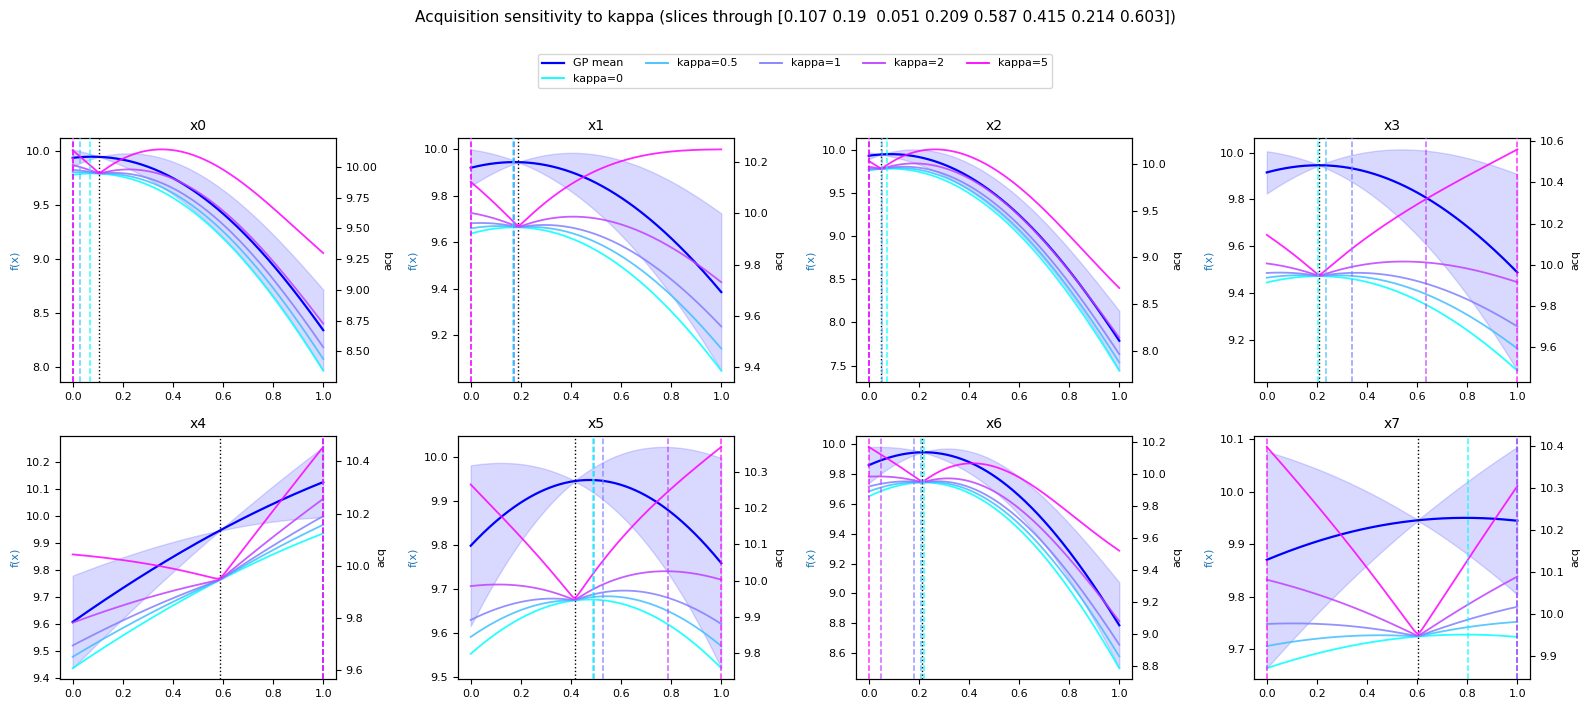


=== restricted to the live axes x[0, 1, 2, 3, 5, 6], holding x[4, 7] at the incumbent ===


 kappa |  pred mean |      gain |  pred std |  UPPER edge |  lower edge |    dist
     0 |    +9.9531 |   +0.0075 |    0.0130 |        none |        none |  0.0828
  0.25 |    +9.9518 |   +0.0063 |    0.0210 |        none |        none |  0.0969
   0.5 |    +9.9375 |   -0.0081 |    0.0582 |        none |        none |  0.1817
     1 |    +9.8989 |   -0.0466 |    0.1128 |        none |      [0, 2] |  0.3100
incumbent y = 9.945552

using kappa = 0.25, searching only x[0, 1, 2, 3, 5, 6]
chosen as the largest kappa whose predicted mean still beats the incumbent:
  kappa=0.0   pred mean +9.953089  gain +0.007537
  kappa=0.25  pred mean +9.951841  gain +0.006289  <- committed
  kappa=0.5   pred mean +9.937488  gain -0.008064
  kappa=1.0   pred mean +9.898935  gain -0.046618


In [9]:
def bound_report(p):
    """Report which coordinates sit on a domain edge, upper and lower separately.

    Bounds are the true domain [0,1], so NEITHER edge is automatically a defect
    -- contact means the constrained optimum is on the boundary, which on a
    monotone axis is exactly right. I judge it per axis against that axis's
    monotone direction (see the axis cell), not by which edge it is.
    """
    upper = [d for d in range(D) if np.isclose(p[d], bounds[d, 1])]
    lower = [d for d in range(D) if np.isclose(p[d], bounds[d, 0])]
    return upper, lower


print("=== unrestricted over all 8 axes (shown to demonstrate the corner problem) ===")
with fitting("kappa sweep (one shared GP)"):
    kappa_rows = compare_kappa_proposals(X, y, bounds, kappa_values=[0.0, 0.5, 1.0, 2.0, 5.0],
                                          maximize=True, n_restarts=40, random_state=0)

print(f"{'kappa':>6} | {'pred mean':>10} | {'on bound':>9} | {'UPPER bound':>22}")
for row in kappa_rows:
    up, lo = bound_report(row["x_next"])
    print(f"{row['kappa']:6g} | {row['pred_mean']:+10.4f} | {len(up) + len(lo):>7}/{D}"
          f" | {str(up) if up else 'none':>22}")

plot_kappa_sensitivity(X, y, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()


def restricted_ucb(kappa, n_starts=100):
    """Maximise UCB over the live axes only, holding flat axes at the incumbent."""
    lo = bounds[live, 0]
    hi = bounds[live, 1]

    def neg(v):
        p = incumbent.copy()
        p[live] = v
        return -ucb_acquisition(normalize(p.reshape(1, -1), bounds), gp_check,
                                 kappa=kappa, maximize=True)[0]

    best_val, best_v = np.inf, None
    rng = np.random.default_rng(0)
    for start in rng.uniform(lo, hi, size=(n_starts, len(live))):
        res = minimize(neg, start, method="L-BFGS-B", bounds=list(zip(lo, hi)))
        if res.fun < best_val:
            best_val, best_v = res.fun, res.x
    p = incumbent.copy()
    p[live] = best_v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    return p, m[0], s[0]


print(f"\n=== restricted to the live axes x{live}, holding x{flat} at the incumbent ===")
# Rows computed once and reused for the criterion below, so the two can't
# disagree and I don't pay for the L-BFGS restarts twice.
_gain_rows = []
for k in [0.0, 0.25, 0.5, 1.0]:
    p, m, s = restricted_ucb(k)
    up, lo_ = bound_report(p)
    _gain_rows.append((k, m, s, up, lo_, float(np.linalg.norm(p - incumbent))))

print(f"{'kappa':>6} | {'pred mean':>10} | {'gain':>9} | {'pred std':>9}"
      f" | {'UPPER edge':>11} | {'lower edge':>11} | {'dist':>7}")
for k, m, s, up, lo_, dist in _gain_rows:
    print(f"{k:6g} | {m:+10.4f} | {m - y.max():+9.4f} | {s:9.4f}"
          f" | {str(up) if up else 'none':>11} | {str(lo_) if lo_ else 'none':>11}"
          f" | {dist:7.4f}")
print(f"incumbent y = {y.max():.6f}")

# My choice, defined here so the proposal, the slice plot and the diagnostics
# replay all read one value and can't drift apart.
#
# Chosen as the largest kappa whose predicted mean still BEATS the incumbent.
# My previous criterion -- "the largest kappa touching no UPPER bound" -- rested
# on upper contact being a pad_fraction artifact, which is false now that bounds
# are the domain.
KAPPA = 0.25
print(f"\nusing kappa = {KAPPA}, searching only x{live}")
print("chosen as the largest kappa whose predicted mean still beats the incumbent:")
for k, m, *_ in _gain_rows:
    mark = "  <- committed" if k == KAPPA else ""
    print(f"  kappa={k:<5} pred mean {m:+.6f}  gain {m - y.max():+.6f}{mark}")

# The verdict cell above reports how the committed setting ranks, which only
# means something if CHOSEN names this KAPPA. Config names follow
# f"ucb_k{kappa:g}", so this is checkable rather than a comment to remember.
_expected = f"ucb_k{KAPPA:g}"
assert CHOSEN == _expected, (
    f"CHOSEN={CHOSEN!r} does not match the committed KAPPA={KAPPA}"
    f" (expected {_expected!r}). The backtest verdict above refers to a config"
    " this notebook does not use -- fix one or the other."
)


## Propose the next point

The live axes come from the restricted UCB search; x4 and x7 are held at the incumbent because the acquisition is effectively flat along them, and letting it choose them pushed x4 onto its upper bound.

This week the cell computes **both** candidates — the `kappa=0.25` acquisition proposal and the x4 confound test — prints them side by side, and takes the test. `USE_CONFOUND_TEST = False` reverts to the acquisition.

The convex-hull check is omitted: at D=8 with 43 points every observation is a hull vertex, so the test carries no information (see the dataset cell). The per-axis range check and the upper/lower edge split are what matter. Expect x4 to show up on the upper edge and outside its observed range — that is the experiment, not a defect, and the cell labels it as such.

In [10]:
USE_CONFOUND_TEST = True     # False -> take the kappa=0.25 acquisition proposal
CONFOUND_AXIS = 4            # the axis frozen across every collected point
CONFOUND_VALUE = 1.0         # the GP's own argmax on that axis; a domain edge

gp = gp_check
x_acq, mu_acq, sigma_acq = restricted_ucb(KAPPA, n_starts=200)

# The controlled test: the incumbent with ONE coordinate moved. Because only x4
# differs, comparing the result against the incumbent's MEASURED y is a clean
# one-factor experiment -- which is the whole point. See the header.
x_test = incumbent.copy()
x_test[CONFOUND_AXIS] = CONFOUND_VALUE
_m, _s = gp.predict(normalize(x_test.reshape(1, -1), bounds), return_std=True)

print("--- candidates ---")
for label, cand, m_, s_ in (("acquisition (kappa=%s)" % KAPPA, x_acq, mu_acq, sigma_acq),
                            ("confound test (x%d -> %.1f)" % (CONFOUND_AXIS, CONFOUND_VALUE),
                             x_test, _m[0], _s[0])):
    print(f"  {label:>28}: pred {m_:+.6f} +/- {s_:.4f}"
          f"  gain {m_ - y.max():+.6f}  step {np.linalg.norm(cand - incumbent):.4f}")

if USE_CONFOUND_TEST:
    x_next, mu_next, sigma_next = x_test, _m[0], _s[0]
    n_diff = int(np.sum(~np.isclose(x_next, incumbent)))
    print(f"\nCHOSEN: the confound test. It differs from the incumbent on exactly"
          f" {n_diff} coordinate(s),")
    print(f"so the result compared with the incumbent's measured {y.max():.6f} isolates"
          f" x{CONFOUND_AXIS}'s effect.")
    print(f"  H1 (GP right): y comes back near {_m[0]:+.2f}, ABOVE the incumbent"
          f" -> x{CONFOUND_AXIS} genuinely helps and should be searched.")
    print(f"  H2 (data right): y comes back BELOW {y.max():.4f} -> the ramp was a"
          f" confound artefact; keep holding x{CONFOUND_AXIS}.")
    print("Either way the confound is broken for next week's refit.")
else:
    x_next, mu_next, sigma_next = x_acq, mu_acq, sigma_acq
    print("\nCHOSEN: the acquisition proposal.")

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu_next:.6f}, predicted std: {sigma_next:.6f}")
print(f"current best observed y: {y.max():.6f}"
      f"  -> predicted improvement: {mu_next - y.max():+.6f}")
held = [d for d in flat if d != CONFOUND_AXIS] if USE_CONFOUND_TEST else flat
print(f"flat axes x{held} held at the incumbent:"
      f" {np.allclose(x_next[held], incumbent[held])}"
      + (f"  (x{CONFOUND_AXIS} is deliberately moved this week)" if USE_CONFOUND_TEST else ""))

# Bounds are the TRUE DOMAIN, so neither edge is automatically a defect. The
# question is whether the axis is monotone toward that edge (expected) or not.
up, lo = bound_report(x_next)
for label, dims, is_upper in (("UPPER", up, True), ("lower", lo, False)):
    print(f"\non the {label} domain edge:", dims or "none")
    for d in dims:
        sr = float(srs[d])
        if d == CONFOUND_AXIS and USE_CONFOUND_TEST:
            print(f"  x{d}: DELIBERATE -- this is the confound test, not the acquisition")
        elif abs(sr) > 0.4 and ((sr > 0) == is_upper):
            print(f"  x{d}: EXPECTED -- monotone (spearman {sr:+.3f}) with its best end here")
        else:
            print(f"  x{d}: QUESTION IT -- spearman {sr:+.3f} does not point this way")

outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")

print(f"\ndistance from the incumbent: {np.linalg.norm(x_next - incumbent):.6f}")
print("nearest 3 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:3]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  y={y[i]:+.6f}")

--- candidates ---
      acquisition (kappa=0.25): pred +9.951841 +/- 0.0210  gain +0.006289  step 0.0969
     confound test (x4 -> 1.0): pred +10.124478 +/- 0.0663  gain +0.178926  step 0.4131

CHOSEN: the confound test. It differs from the incumbent on exactly 1 coordinate(s),
so the result compared with the incumbent's measured 9.945552 isolates x4's effect.
  H1 (GP right): y comes back near +10.12, ABOVE the incumbent -> x4 genuinely helps and should be searched.
  H2 (data right): y comes back BELOW 9.9456 -> the ramp was a confound artefact; keep holding x4.
Either way the confound is broken for next week's refit.

--- Next point to evaluate (bounds shape (8, 2)) ---
x_next: [0.106878 0.190311 0.050599 0.209113 1.       0.414903 0.21378  0.603135]
3.43**2 * Matern(length_scale=[3.12, 4.89, 2.59, 4.96, 10, 5.17, 3.17, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)
GP predicted mean: 10.124478, predicted std: 0.066270
current best observed y: 9.945552  -> predicted improvement: +0.

## Visualise the GP and acquisition function via 1D slices

Eight panels, each holding the other seven dimensions at the current best observed point and sweeping one. Dotted line is the fixed centre, dashed red is `x_next`, green is UCB.

I expect **x7 to be a flat line and x4 to be nearly straight** — their ranges are about 0.080 and 0.516 against x2's 2.161. x4's near-linearity is the ramp the header is about: it looks like a mild upward trend, and the whole question this week is whether that is real or an artefact of x4 being frozen across my three collected points. x0, x2 and x6 should show the most structure, matching both the length-scales and the rank correlations.

A *partial* view, and more so here than anywhere else: eight 1D slices through one point say nothing about interactions, and at D=8 that omission covers essentially all of the space. A sanity check on marginal behaviour, not a picture of the surface.

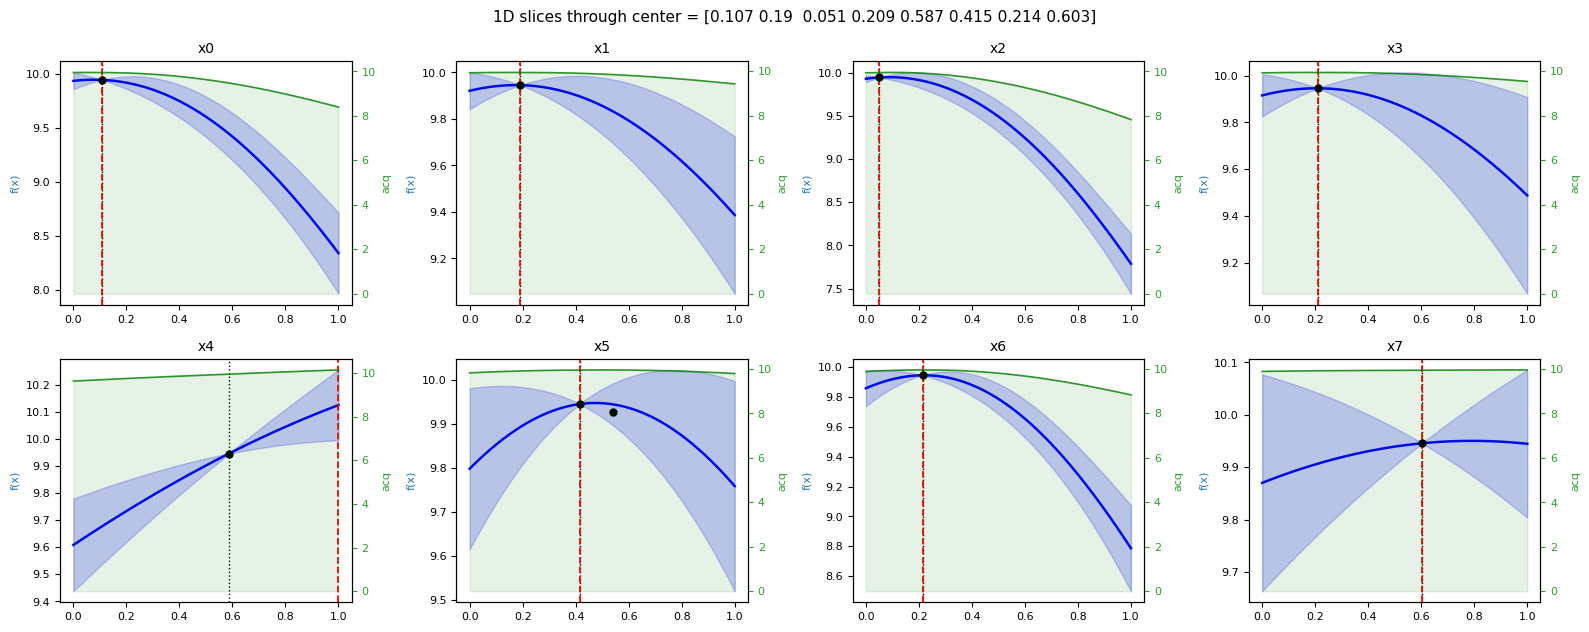

In [11]:
plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
)
plt.show()

## Sanity-check the surrogate: leave-one-out calibration

Refits once per observation, holding it out and predicting it from the rest. At D=8 this is essentially the only way I can judge the surrogate — the slice plots cover a vanishing fraction of the space.

This is my best coverage anywhere: **40 of 43** points inside their own 95% interval, with the worst-predicted being an ordinary initial observation (index 28) missed by −2.2 sigma. Not the incumbent, and not one of the collected points — all three of those were predicted out-of-sample to within 1.2 sigma before they arrived.

`random_state` is pinned here. `gp_kwargs` is forwarded to `fit_gp` on every one of the 43 refits, so unseeded this cell was not reproducible between runs, and a claim about *which* point is worst-predicted is meaningless unless it is seeded.

[fitting: leave-one-out calibration] 131 warnings held back, 5 distinct:
    43 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
    43 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
    43 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 5) pinned at upper bound 10.0
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 3) pinned at upper bound 10.0


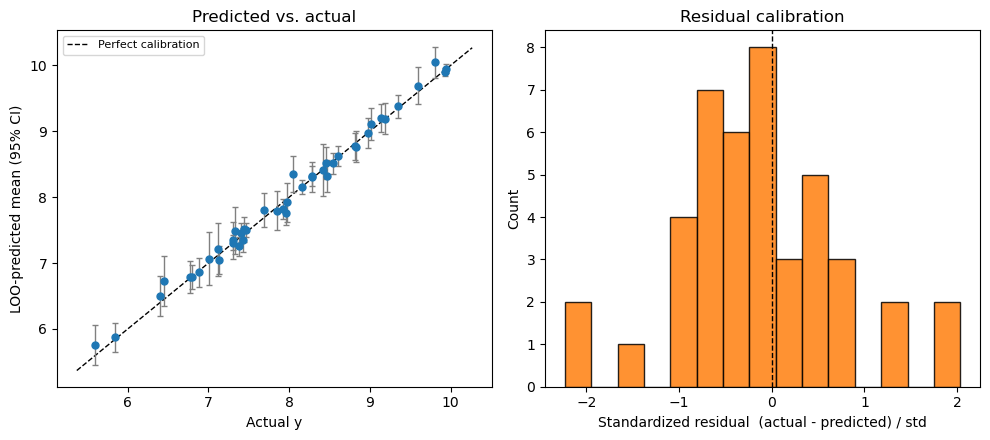

points inside their own 95% LOO interval: 40/43
worst-predicted: index 28 -> true 8.042213, predicted 8.354160 (std 0.139806) = -2.2 sigma
  that point comes from the initial batch
is it the incumbent? False


In [12]:
# random_state is pinned: gp_kwargs goes to fit_gp on every one of the 43
# refits, so unseeded this cell was not reproducible run to run -- and the
# markdown states which point is worst-predicted, so that has to be stable.
with fitting("leave-one-out calibration"):
    pred_mean, pred_std = loo_predictions(
        X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20, "random_state": 0})

plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")
worst = int(np.argmax(np.abs(y - pred_mean)))
print(f"worst-predicted: index {worst} -> true {y[worst]:.6f},"
      f" predicted {pred_mean[worst]:.6f} (std {pred_std[worst]:.6f})"
      f" = {(y[worst] - pred_mean[worst]) / pred_std[worst]:+.1f} sigma")
src = ("the initial batch" if worst < n_initial
       else f"collected week {worst - n_initial + 2}")
print(f"  that point comes from {src}")
print("is it the incumbent?", worst == int(np.argmax(y)))


## Iteration diagnostics

Replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters and domain-wide uncertainty were at each past proposal. No persisted log involved.

**`domain_grid_n` has to come down drastically at D=8.** Its `domain_mean_std` field averages posterior std over a `domain_grid_n ** D` grid, so the default 40 means `40**8 = 6.6e12` points — about **419,000 GB**. Even 10 would be 1e8. The cell sizes the grid so the count stays near 200,000, which gives `domain_grid_n = 4` here: four samples per axis.

At that resolution `domain_mean_std` is a very coarse estimate. It stays usable for comparing one iteration against another *within this notebook*, since every iteration uses the same grid, but its absolute value means little and it is not comparable across notebooks.

Two caveats. The `kappa` comes from `KAPPA` so it cannot drift from what the proposal used, but my history is **mixed** — the three collected rows were not all proposed under `ucb`/`kappa=0.25`, and `compute_iteration_diagnostics` applies one setting across the whole replay, so `acq_value` is an artefact of that mismatch rather than a property of any point. The GP-hyperparameter and `domain_mean_std` columns don't depend on the acquisition and are fine throughout.

`plot_bo_diagnostics` is skipped, since it hard-codes a 2D scatter panel. The trend plots below are dimension-agnostic and gated on having at least three completed iterations.

domain_grid_n = 4 -> 65,536 grid points (the default 40 would be 6,553,600,000,000)
domain_mean_std is therefore very coarse: comparable across iterations
within this notebook, not across notebooks or grid sizes.


[fitting: iteration-diagnostics replay] 9 warnings held back, 3 distinct:
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 4) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k1__k2__length_scale (dim 7) pinned at upper bound 10.0
     3 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06

Best y so far: 9.9455521132595

CAVEAT: my history is MIXED -- the 3 collected rows were not all
proposed under ucb/kappa=0.25, and compute_iteration_diagnostics applies one
setting across the whole replay. So acq_value is an artefact of that mismatch
rather than a property of any point. The GP-hyperparameter and domain_mean_std
columns don't depend on the acquisition and are fine throughout.
completed iterations in the modelling set: 3


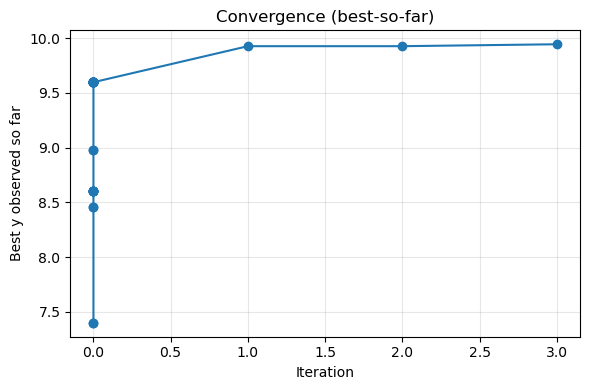

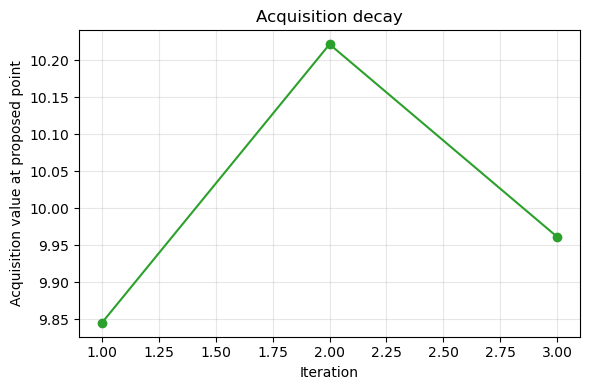

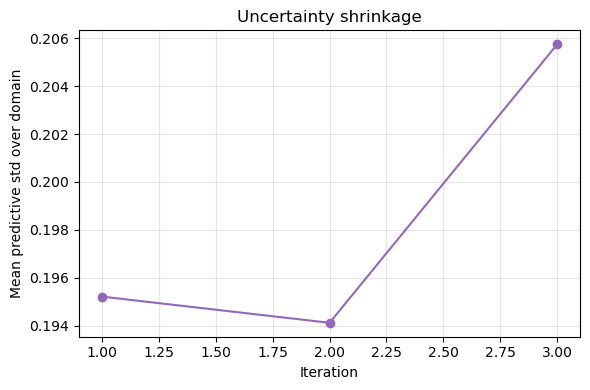

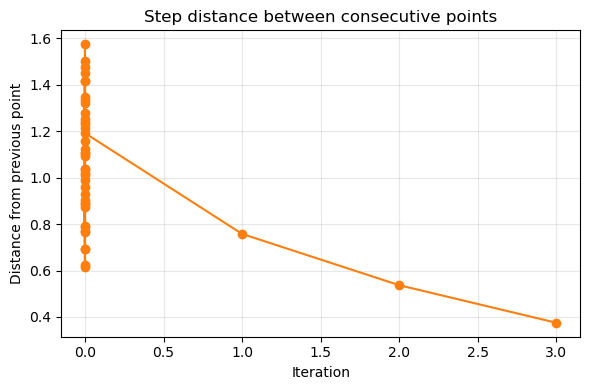

In [13]:
# compute_iteration_diagnostics builds a domain_grid_n ** D grid. The default 40
# is 40**8 = 6.6e12 points (~419,000 GB) at D=8. Size it so the grid stays near
# 200k points whatever D is -- here that means just 4 samples per axis.
DOMAIN_GRID_N = max(3, int(200_000 ** (1.0 / D)))
print(f"domain_grid_n = {DOMAIN_GRID_N} -> {DOMAIN_GRID_N ** D:,} grid points"
      f" (the default 40 would be {40 ** D:,})")
print("domain_mean_std is therefore very coarse: comparable across iterations")
print("within this notebook, not across notebooks or grid sizes.")

# The count comes from the MODELLING set rather than len(new_y), so it stays
# correct if I ever exclude rows from the fit.
n_replayed = len(y) - n_initial

with fitting("iteration-diagnostics replay"):
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                            acquisition="ucb", kappa=KAPPA,
                                            maximize=True,
                                            domain_grid_n=DOMAIN_GRID_N)

print("\nBest y so far:", np.nanmax(history["y"]))
print(f"\nCAVEAT: my history is MIXED -- the {n_replayed} collected rows were not all")
print(f"proposed under ucb/kappa={KAPPA}, and compute_iteration_diagnostics applies one")
print("setting across the whole replay. So acq_value is an artefact of that mismatch")
print("rather than a property of any point. The GP-hyperparameter and domain_mean_std")
print("columns don't depend on the acquisition and are fine throughout.")
print("completed iterations in the modelling set:", n_replayed)

if n_replayed >= 3:
    for plot_fn in (plot_convergence, plot_acquisition_decay,
                    plot_uncertainty_shrinkage, plot_step_distance):
        plot_fn(history)
        plt.show()
else:
    print(f"\nOnly {n_replayed} replayed iteration(s) -- need at least 3 before the")
    print("trend plots say anything. Skipping them; the raw fields are below.")

## Raw diagnostic fields

In [14]:
print("y (last 5):", np.round(history["y"][-5:], 5))
print("iteration (last 5):", history["iteration"][-5:])
obs = ~np.isnan(history["acq_value"])
print("\nfor the proposed (non-initial) points only:")
print("  acq_value      :", history["acq_value"][obs])
print("  pred_mean      :", history["pred_mean"][obs])
print("  actual y       :", history["y"][obs])
print("  length_scale   :", history["length_scale"][obs])
print("  domain_mean_std:", history["domain_mean_std"][obs])

y (last 5): [7.43659 9.18301 9.92799 9.80205 9.94555]
iteration (last 5): [0. 0. 1. 2. 3.]

for the proposed (non-initial) points only:
  acq_value      : [ 9.84508121 10.22135894  9.96113883]
  pred_mean      : [ 9.82340141 10.17155214  9.95245153]
  actual y       : [9.92798929 9.80205265 9.94555211]
  length_scale   : [5.90483096 5.81579671 5.41507198]
  domain_mean_std: [0.19520886 0.19411376 0.20575545]


In [15]:
# My proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision too. I submit the 6-dp string; the store keeps 6 dp as well,
# which is what actually gets evaluated.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.106878-0.190311-0.050599-0.209113-1.000000-0.414903-0.213780-0.603135

full precision (use for next week's new_X):
0.106878-0.190311-0.050599-0.209113-1.0-0.414903-0.21378-0.603135


In [16]:
# I record this week's proposal in the weekly store. This rewrites inputs.csv
# rather than appending, so re-running the notebook cannot double-record. I
# submit the 6-dp string printed above -- it is the same value written here.
save_proposal(8, new_X, x_next)


wrote weekly_data/function_8/inputs.csv: 4 row(s) (3 resulted + 1 proposal)
  proposal row: 0.106878-0.190311-0.050599-0.209113-1.000000-0.414903-0.213780-0.603135


'weekly_data/function_8/inputs.csv'